# Practical Session 01e &mdash; Your first end-to-end ML pipeline

**Companion to Lecture&nbsp;01.** This notebook ties the series together into one honest,
leak-free workflow &mdash; applying the train/validation/test discipline from **01d**: from a messy table to a trained, evaluated model &mdash; the "first end-to-end
example" and the "ML workflow loop" from the lecture, made concrete.

We build it the **production way**: cleaning, imputation, scaling, and encoding all live inside
a single scikit-learn **`Pipeline`**, so every data-dependent step is fitted on the *training
split only*. That one habit is what separates an honest score from a fooling one.

> ⭐ **Key idea.** A `Pipeline` is a model *and* all its preprocessing bundled into one object.
> `.fit(train)` learns everything from the training data; `.predict(test)` applies it &mdash; with
> no chance of the test set leaking in.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nb_utils import use_style
from nb_data import make_apartments, basic_clean

use_style("notes")
np.set_printoptions(precision=2, suppress=True)
print("ready")

ready


## 1. Frame the problem: $T$, $P$, $E$

The lecture's Mitchell definition &mdash; a program learns from **experience $E$** at some **task
$T$**, measured by **performance $P$** &mdash; is a checklist for *any* project:

* **Task $T$:** predict an apartment's **monthly rent** from its attributes. The target is a
  number ⇒ **supervised regression**.
* **Performance $P$:** how close predictions are &mdash; **MAE** (avg. euros off), **RMSE** (penalizes
  big misses), and **R&sup2;** (fraction of variance explained).
* **Experience $E$:** the apartments table (labelled examples of attributes → rent).

## 2. Load, clean, and separate $\mathbf{X}$ / $\mathbf{y}$

We start from the messy table (01c) and apply the *structural* cleaning from
`nb_data.basic_clean` &mdash; which fixes dtypes, categories, impossible values, and duplicates,
but **leaves genuine missing values** for the pipeline's imputer to handle on the training
split.

In [2]:
df = basic_clean(make_apartments(n=400, seed=0, messy=True))
X = df.drop(columns="rent_eur")
y = df["rent_eur"]
print("X:", X.shape, "| y:", y.shape)
print("missing values still present (the imputer will handle these):")
print(X.isna().sum()[X.isna().sum() > 0].to_dict())

X: (400, 8) | y: (400,)
missing values still present (the imputer will handle these):
{'area_m2': 25, 'building_age': 33, 'dist_center_km': 21}


## 3. Split off a test set &mdash; and don't touch it

The test set is the **final exam**: used exactly once, at the very end. Everything &mdash; model
choice, tuning, preprocessing &mdash; is decided on the training data (via cross-validation).

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape[0], "examples  |  test:", X_test.shape[0], "examples (held out)")

train: 320 examples  |  test: 80 examples (held out)


## 4. Split-safe preprocessing with a `ColumnTransformer`

Numeric and categorical columns need different treatment. A **`ColumnTransformer`** applies:

* to **numeric** columns: impute missing with the **median**, then **standardize**;
* to the **categorical** column: impute with the most frequent value, then **one-hot** encode.

Wrapping it in a `Pipeline` with an estimator means `.fit` learns the medians, means, stds, and
categories from the **training fold only**.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["area_m2", "rooms", "bathrooms", "floor", "building_age", "dist_center_km"]
cat_cols = ["neighborhood"]
bool_cols = ["has_elevator"]

numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())])
categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocess = ColumnTransformer([
    ("num", numeric, num_cols),
    ("cat", categorical, cat_cols),
    ("bool", "passthrough", bool_cols),
])
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## 5. Always start with a baseline

Before any real model, ask: *what score does a trivial rule get?* A `DummyRegressor` that
always predicts the mean rent is the number every real model must beat.

In [5]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

def evaluate(model, Xte, yte, name):
    pred = model.predict(Xte)
    return {"model": name,
            "MAE":  mean_absolute_error(yte, pred),
            "RMSE": root_mean_squared_error(yte, pred),
            "R2":   r2_score(yte, pred)}

baseline = Pipeline([("prep", preprocess), ("model", DummyRegressor(strategy="mean"))])
baseline.fit(X_train, y_train)
pd.DataFrame([evaluate(baseline, X_test, y_test, "baseline (mean)")]).round(2)

,model,MAE,RMSE,R2
0,baseline (mean),334.95,418.73,-0.0


## 6. Compare models with cross-validation (not the test set)

To choose between models we use **k-fold cross-validation on the training set**: split the
training data into k folds, train on k&minus;1 and validate on the held-out one, rotate, and
average. This gives an honest estimate *and a spread* &mdash; without ever touching the test set.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

candidates = {
    "baseline (mean)":   DummyRegressor(strategy="mean"),
    "linear regression": LinearRegression(),
    "random forest":     RandomForestRegressor(n_estimators=200, random_state=0),
}

rows = []
for name, est in candidates.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    cv = cross_validate(pipe, X_train, y_train, cv=5,
                        scoring=["neg_root_mean_squared_error", "r2"])
    rows.append({"model": name,
                 "CV RMSE": -cv["test_neg_root_mean_squared_error"].mean(),
                 "CV RMSE std": cv["test_neg_root_mean_squared_error"].std(),
                 "CV R2": cv["test_r2"].mean()})
cv_table = pd.DataFrame(rows).round(2)
cv_table

,model,CV RMSE,CV RMSE std,CV R2
0,baseline (mean),435.69,42.88,-0.03
1,linear regression,158.69,11.04,0.86
2,random forest,187.69,21.43,0.81


> 💡 **Reading the table.** Lower RMSE and higher R&sup2; are better. Both real models crush the
> baseline; the winner (by CV RMSE) is what we commit to. The `std` column matters too &mdash; a
> model that is a little worse but much more stable is often the safer pick.

## 7. Fit the winner and score it **once** on the test set

Cross-validation picked the model. Now refit it on the *full* training set and report the
single, honest test score.

In [7]:
best_name = cv_table.sort_values("CV RMSE").iloc[0]["model"]
best = Pipeline([("prep", preprocess), ("model", candidates[best_name])]).fit(X_train, y_train)
print("selected by cross-validation:", best_name)
pd.DataFrame([evaluate(best, X_test, y_test, best_name + " (TEST)")]).round(2)

selected by cross-validation: linear regression


,model,MAE,RMSE,R2
0,linear regression (TEST),126.56,161.35,0.85


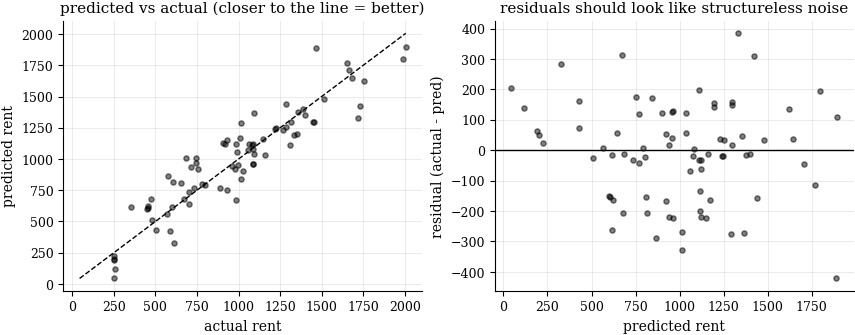

In [8]:
pred = best.predict(X_test)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.4))
a1.scatter(y_test, pred, s=14, alpha=0.5)
lim = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
a1.plot(lim, lim, "k--", lw=1); a1.set_xlabel("actual rent"); a1.set_ylabel("predicted rent")
a1.set_title("predicted vs actual (closer to the line = better)")
resid = y_test - pred
a2.scatter(pred, resid, s=14, alpha=0.5); a2.axhline(0, color="k", lw=1)
a2.set_xlabel("predicted rent"); a2.set_ylabel("residual (actual - pred)")
a2.set_title("residuals should look like structureless noise")
for a in (a1, a2): a.grid(alpha=0.3)
plt.show()

## 8. Overfitting, made visible

The lecture warned: a flexible model can *memorize* the training data yet fail to generalize.
We can watch it happen by sweeping a single **decision tree's `max_depth`** (its flexibility)
and plotting training error against cross-validated error &mdash; the classic gap.

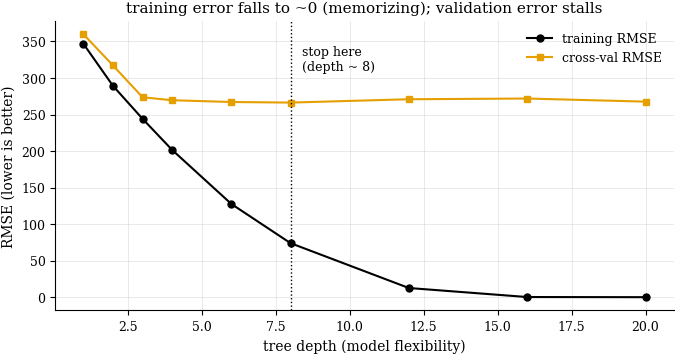

In [9]:
from sklearn.model_selection import validation_curve
from sklearn.tree import DecisionTreeRegressor

depths = [1, 2, 3, 4, 6, 8, 12, 16, 20]
pipe = Pipeline([("prep", preprocess),
                 ("model", DecisionTreeRegressor(random_state=0))])
train_sc, val_sc = validation_curve(
    pipe, X_train, y_train, param_name="model__max_depth", param_range=depths,
    cv=5, scoring="neg_root_mean_squared_error")

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.plot(depths, -train_sc.mean(1), "o-", label="training RMSE")
ax.plot(depths, -val_sc.mean(1), "s-", label="cross-val RMSE")
best_d = depths[np.argmin(-val_sc.mean(1))]
ax.axvline(best_d, color="k", ls=":", lw=1)
ax.text(best_d + 0.4, ax.get_ylim()[1] * 0.82, f"stop here\n(depth ~ {best_d})", fontsize=9)
ax.set_xlabel("tree depth (model flexibility)"); ax.set_ylabel("RMSE (lower is better)")
ax.set_title("training error falls to ~0 (memorizing); validation error stalls")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

> 🔬 **Going deeper.** As the tree deepens, **training** RMSE plunges toward **zero** &mdash; the tree
> is carving out a leaf for essentially every training apartment (pure memorization). But
> **validation** RMSE bottoms out early and then stops improving: the extra depth buys nothing
> on unseen data. That widening gap between the two curves *is* overfitting &mdash; the
> *bias&ndash;variance tradeoff* from the slides, in one picture. We would cap the depth near that
> minimum, chosen on validation, **never** on the test set. Sessions&nbsp;03 (regularization) and
> 09 (ensembles) return to this in depth.

## 9. Under the hood: training = rolling downhill on the loss

`LinearRegression().fit(...)` felt like magic. The lecture's gradient-descent animation showed
what it really does: start somewhere, repeatedly step *against* the gradient of the loss until
it stops improving. Here it is from scratch on our preprocessed features &mdash; and it reaches the
same solution (the same loss, the same predictions) scikit-learn computes in closed form.

final training MSE  ->  gradient descent: 22,396   sklearn (exact): 22,396
do the predictions agree?  max |gd - sklearn| = 0.0003 EUR


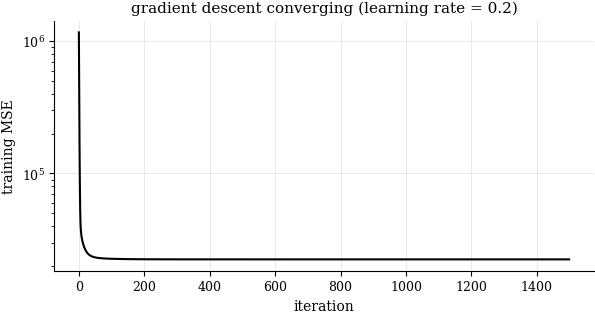

In [10]:
# preprocessed, all-numeric training matrix (fit on train only)
Xtr = preprocess.fit_transform(X_train).astype(float)
ytr = y_train.to_numpy(float)
Xb = np.c_[np.ones(len(Xtr)), Xtr]          # prepend a bias column
w = np.zeros(Xb.shape[1])

lr = 0.2                                     # <-- CHANGE ME: try 0.02 (slow), 0.6 (fast)
losses = []
for step in range(1500):
    err = Xb @ w - ytr
    grad = (Xb.T @ err) / len(ytr)           # gradient of the mean squared error
    w -= lr * grad                           # step downhill
    losses.append(np.mean(err**2))

from sklearn.linear_model import LinearRegression
sk = LinearRegression().fit(Xtr, ytr)
pred_gd, pred_sk = Xb @ w, sk.predict(Xtr)
print(f"final training MSE  ->  gradient descent: {losses[-1]:,.0f}   sklearn (exact): {np.mean((pred_sk - ytr)**2):,.0f}")
print(f"do the predictions agree?  max |gd - sklearn| = {np.abs(pred_gd - pred_sk).max():.4f} EUR")

fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.plot(losses); ax.set_xlabel("iteration"); ax.set_ylabel("training MSE")
ax.set_title(f"gradient descent converging (learning rate = {lr})"); ax.set_yscale("log"); ax.grid(alpha=0.3)
plt.show()

The loss falls smoothly and gradient descent's predictions match scikit-learn's to a fraction
of a cent &mdash; two routes to the same minimum.

> 🔬 **Going deeper.** Notice we compared **predictions**, not individual weights. The
> preprocessed matrix is *rank-deficient*: the five one-hot `neighborhood` columns always sum to
> 1, which is exactly the bias column &mdash; the **dummy-variable trap** from 01a. So infinitely
> many weight vectors give **identical predictions**, and gradient descent (from `w=0`) and
> scikit-learn's solver simply land on different-but-equivalent ones. The fix when you need
> unique, interpretable weights is `OneHotEncoder(drop="first")` or a regularizer (Ridge/Lasso,
> Session&nbsp;03). The predictions &mdash; what we actually deploy &mdash; are unaffected.

## 10. Inspect what the model learned, then save it

A trained model should be interpretable enough to sanity-check. For the random forest, feature
**importances** tell us which attributes drive the rent prediction.

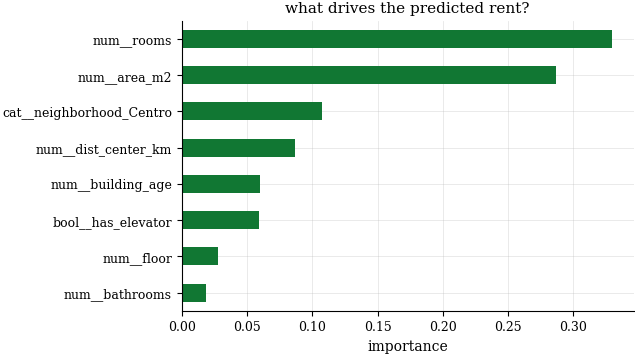

In [11]:
rf = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(n_estimators=200, random_state=0))])
rf.fit(X_train, y_train)
names = rf.named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf.named_steps["model"].feature_importances_, index=names).sort_values()

fig, ax = plt.subplots(figsize=(6.4, 3.6))
imp.tail(8).plot.barh(ax=ax, color="#117733")
ax.set_xlabel("importance"); ax.set_title("what drives the predicted rent?"); ax.grid(alpha=0.3, axis="x")
plt.show()

In [12]:
# Persist the whole pipeline (preprocessing + model) as one deployable artifact.
import joblib, tempfile, os
path = os.path.join(tempfile.gettempdir(), "rent_pipeline.joblib")
joblib.dump(best, path)
reloaded = joblib.load(path)

# a brand-new apartment -> a rent prediction, straight from raw feature values
new = pd.DataFrame([{
    "area_m2": 85, "rooms": 3, "bathrooms": 2, "floor": 4, "building_age": 12,
    "neighborhood": "Centro", "has_elevator": True, "dist_center_km": 2.5,
}])
print("saved pipeline to:", path)
print(f"predicted rent for the new apartment: {reloaded.predict(new)[0]:,.0f} EUR/month")

saved pipeline to: C:\Users\JAN\AppData\Local\Temp\rent_pipeline.joblib
predicted rent for the new apartment: 1,564 EUR/month


> 🔬 **Going deeper.** `joblib.dump` saves the *entire* pipeline &mdash; imputers, scaler, encoder,
> and model &mdash; so deployment is just `joblib.load(...).predict(new_raw_rows)`. The new
> apartment above is passed as **raw** feature values (text neighborhood, possible missing
> fields); the pipeline handles all preprocessing identically to training. That is the payoff
> of putting everything in one object.

## Recap & exercises

**Recap &mdash; the workflow, in order.**
1. **Frame** the task with $T$, $P$, $E$.
2. **Clean** structurally; leave true missingness for the pipeline.
3. **Split off a test set** and don't touch it.
4. Put imputation + scaling + encoding in a **`ColumnTransformer` / `Pipeline`** (no leakage).
5. Establish a **baseline**.
6. **Cross-validate** to compare and select models.
7. Refit the winner; score **once** on the test set; read the residuals.
8. Diagnose **overfitting** with a train-vs-validation curve.
9. Remember: training is **gradient descent** minimizing a loss.
10. **Inspect** and **save** the pipeline for reuse.

**Exercises.**
1. Add `GradientBoostingRegressor` (or `Ridge`) to `candidates`. Does it win on CV RMSE?
2. In section&nbsp;9, set `lr = 0.005` and `lr = 0.2`. Which crawls, which diverges, and how do
   the loss curves differ?
3. Remove the `StandardScaler` from the numeric pipeline. Does linear regression change? Does
   gradient descent (section&nbsp;9) still converge at the same learning rate? (Scaling matters
   for gradients!)
4. Replace `train_test_split` random state and re-run: how much does the single test score move?
   Why is cross-validation a more stable basis for decisions?
5. Engineer a feature `rent_per_m2` from the target and add it to `X`. Watch the test R&sup2;
   jump to ~1.0 &mdash; then explain why this is **leakage**, not success.

*You have now built a complete, honest ML pipeline.* **Next session:** Lecture&nbsp;02 &mdash; Linear
Regression, where we open up the model in section&nbsp;9 and make its every part precise.